In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df = pd.read_csv("/content/Telco_Customer_Churn_Dataset  (3).csv")

In [6]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [7]:
df.shape

(7043, 21)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [10]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


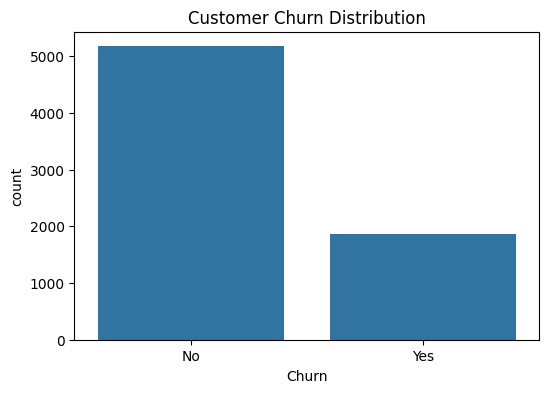

In [12]:
plt.figure(figsize=(6,4))
sns.countplot(x='Churn', data=df)
plt.title("Customer Churn Distribution")
plt.show()

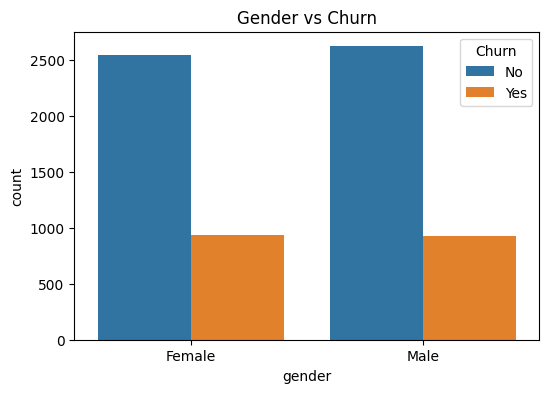

In [14]:
plt.figure(figsize=(6,4))
sns.countplot(x='gender', hue='Churn', data=df)
plt.title("Gender vs Churn")
plt.show()

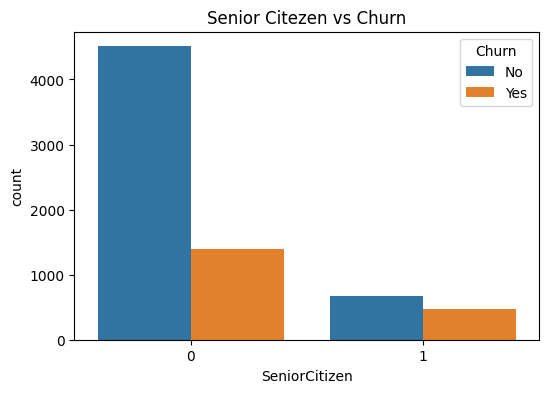

In [16]:
plt.figure(figsize=(6,4))
sns.countplot(x='SeniorCitizen', hue='Churn', data=df)
plt.title("Senior Citezen vs Churn")
plt.show()

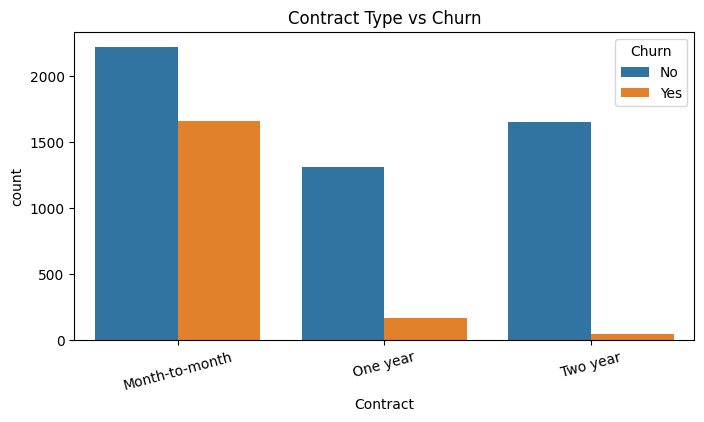

In [18]:
plt.figure(figsize=(8,4))
sns.countplot(x='Contract', hue='Churn', data=df)
plt.title("Contract Type vs Churn")
plt.xticks(rotation=15)
plt.show()

Text(0.5, 1.0, 'Monthly Charges Distribution')

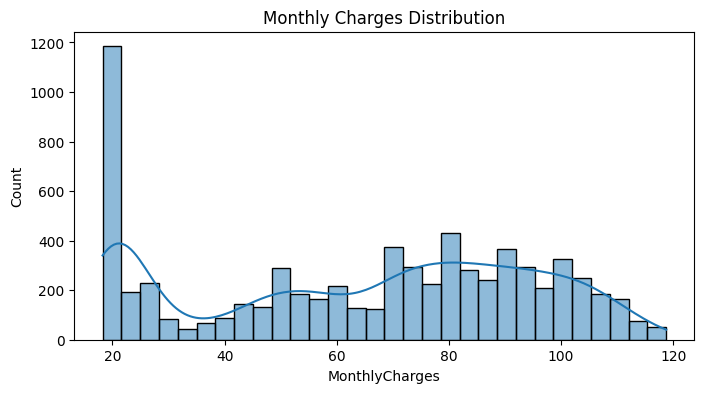

In [19]:
plt.figure(figsize=(8,4))
sns.histplot(df['MonthlyCharges'], bins=30, kde=True)
plt.title("Monthly Charges Distribution")

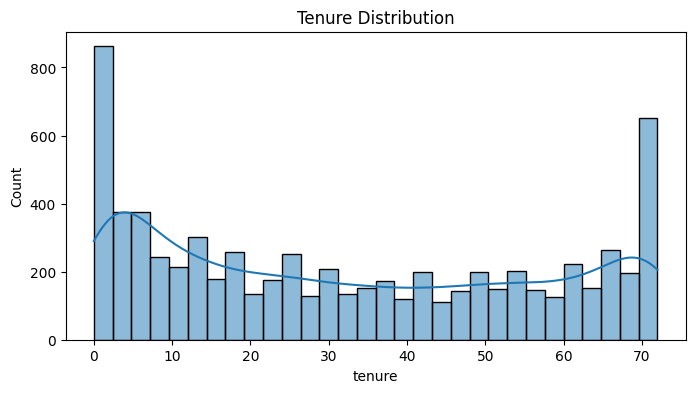

In [21]:
plt.figure(figsize=(8,4))
sns.histplot(df['tenure'], bins=30, kde=True)
plt.title("Tenure Distribution")
plt.show()

In [22]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [23]:
df['TotalCharges'].dtype

dtype('O')

In [24]:
df.duplicated().sum()

np.int64(0)

In [25]:
df['TotalCharges'].dtype

dtype('O')

In [26]:
df['Churn'].value_counts()

,count
Churn,
No,5174
Yes,1869


In [27]:
df['Churn'].value_counts(normalize=True)*100

,proportion
Churn,
No,73.463013
Yes,26.536987


In [28]:
df.drop('customerID', axis=1, inplace=True)

In [31]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
for col in df.columns:
  if df[col].dtype == 'object': df[col] = le.fit_transform(df[col])

In [47]:
X = df.drop('Churn', axis=1)
y = df['Churn']

In [48]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y,
test_size=0.2,
random_state=42
)

In [51]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000)

In [52]:
y_pred = model.predict(X_test)

In [53]:
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.8168914123491838


In [54]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[938  98]
 [160 213]]


The model correctly predicted 938 non-churn customers and 213 churn customers. However, it misclassified 160 actual churn customers, indicating that recall needs improvement.

In [56]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.85      0.91      0.88      1036
           1       0.68      0.57      0.62       373

    accuracy                           0.82      1409
   macro avg       0.77      0.74      0.75      1409
weighted avg       0.81      0.82      0.81      1409



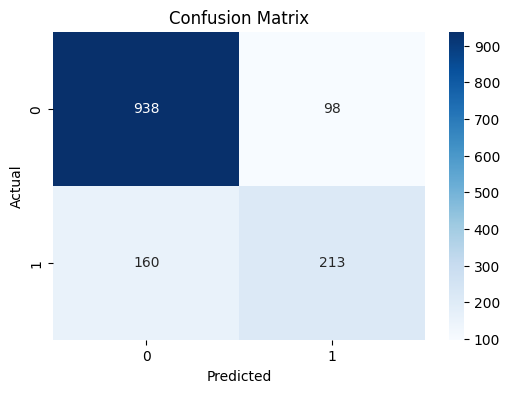

In [57]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True,
            fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [70]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(n_estimators=100,random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

In [69]:
from sklearn.metrics import accuracy_score
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))

Random Forest Accuracy: 0.7984386089425124


In [68]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)

In [71]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_prob = rf.predict_proba(X_test)[:,1]

from sklearn.metrics import roc_auc_score
print("ROC-AUC Score:", roc_auc_score(y_test, y_prob))

ROC-AUC Score: 0.8347881105924002


The model achieved an ROC-AUC score of 0.83, indicating strong ability to distinguish between churn and non-churn customers.

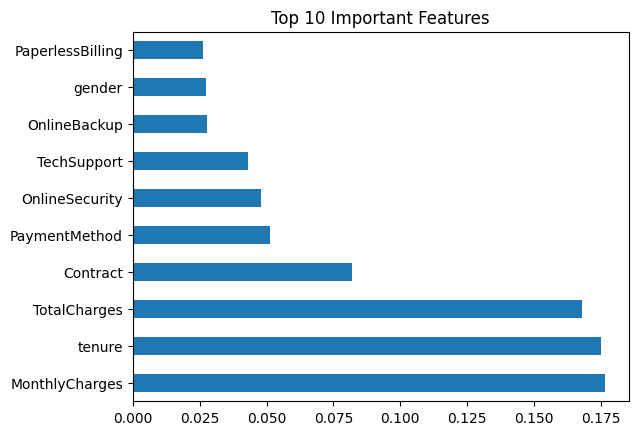

In [72]:
import pandas as pd
import matplotlib.pyplot as plt

importances = rf.feature_importances_
features = X.columns

feat_imp = pd.Series(importances, index=features)
feat_imp.sort_values(ascending=False).head(10).plot(kind='barh')
plt.title("Top 10 Important Features")
plt.show()

In [73]:
rf_balanced = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',
    random_state=42
)

rf_balanced.fit(X_train, y_train)
y_pred_bal = rf_balanced.predict(X_test)

from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred_bal))

              precision    recall  f1-score   support

           0       0.83      0.92      0.87      1036
           1       0.67      0.46      0.55       373

    accuracy                           0.80      1409
   macro avg       0.75      0.69      0.71      1409
weighted avg       0.78      0.80      0.78      1409



In [75]:
y_prob = rf.predict_proba(X_test)[:,1]
y_pred_new = (y_prob > 0.4).astype(int)
print(classification_report(y_test, y_pred_new))

              precision    recall  f1-score   support

           0       0.86      0.85      0.85      1036
           1       0.59      0.60      0.59       373

    accuracy                           0.78      1409
   macro avg       0.72      0.72      0.72      1409
weighted avg       0.78      0.78      0.78      1409



In [76]:
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_new))

Confusion Matrix:
[[877 159]
 [148 225]]


In [77]:
from sklearn.metrics import accuracy_score
print("New Accuracy:", accuracy_score(y_test, y_pred_new))

New Accuracy: 0.7821149751596878


In [79]:
from sklearn.metrics import recall_score, precision_score, accuracy_score

In [80]:
for t in [0.5, 0.4, 0.3]:
    y_pred_temp = (y_prob > t).astype(int)
    print("Threshold:", t)
    print("Recall:", recall_score(y_test, y_pred_temp))
    print("Precision:", precision_score(y_test, y_pred_temp))
    print("Accuracy:", accuracy_score(y_test, y_pred_temp))
    print("---------------------")

Threshold: 0.5
Recall: 0.48525469168900803
Precision: 0.663003663003663
Accuracy: 0.7984386089425124
---------------------
Threshold: 0.4
Recall: 0.6032171581769437
Precision: 0.5859375
Accuracy: 0.7821149751596878
---------------------
Threshold: 0.3
Recall: 0.7453083109919572
Precision: 0.5265151515151515
Accuracy: 0.7551454932576295
---------------------


By reducing the threshold from 0.5 to 0.4, recall improved, allowing the model to detect more churn customers at the cost of slight precision reduction. Since churn prediction is recall-sensitive, the adjusted threshold was preferred

In [81]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

seg_features = df[['tenure','MonthlyCharges','TotalCharges']]

scaler = StandardScaler()
scaled_data = scaler.fit_transform(seg_features)

kmeans = KMeans(n_clusters=3, random_state=42)
df['Segment'] = kmeans.fit_predict(scaled_data)

df.groupby('Segment').mean()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
Segment,,,,,,,,,,,,,,,,,,,,
0,0.510368,0.141137,0.436120,0.296656,25.763880,0.871906,0.794983,0.961204,0.735117,0.787960,0.768562,0.725084,0.827425,0.828763,0.558863,0.531438,1.680936,54.056054,1381.625753,0.276923
1,0.504102,0.217867,0.678213,0.333181,57.906108,0.951686,1.480401,0.675023,1.060164,1.330902,1.355515,1.097539,1.443938,1.453965,1.141294,0.699635,1.143573,91.071832,4301.654057,0.161349
2,0.496503,0.130178,0.328133,0.264658,12.861754,0.896181,0.537386,0.964497,0.559441,0.596019,0.590640,0.558365,0.698225,0.711135,0.370091,0.563206,1.911243,50.929209,5043.439484,0.369554


K-Means clustering identified a high-risk customer segment characterized by low tenure and high monthly charges, showing the highest churn rate.

In [82]:
df.groupby('Segment')['Churn'].mean()

,Churn
Segment,
0,0.276923
1,0.161349
2,0.369554


In [83]:
df.groupby('Segment').mean()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
Segment,,,,,,,,,,,,,,,,,,,,
0,0.510368,0.141137,0.436120,0.296656,25.763880,0.871906,0.794983,0.961204,0.735117,0.787960,0.768562,0.725084,0.827425,0.828763,0.558863,0.531438,1.680936,54.056054,1381.625753,0.276923
1,0.504102,0.217867,0.678213,0.333181,57.906108,0.951686,1.480401,0.675023,1.060164,1.330902,1.355515,1.097539,1.443938,1.453965,1.141294,0.699635,1.143573,91.071832,4301.654057,0.161349
2,0.496503,0.130178,0.328133,0.264658,12.861754,0.896181,0.537386,0.964497,0.559441,0.596019,0.590640,0.558365,0.698225,0.711135,0.370091,0.563206,1.911243,50.929209,5043.439484,0.369554


Segment-wise tenure variation observed

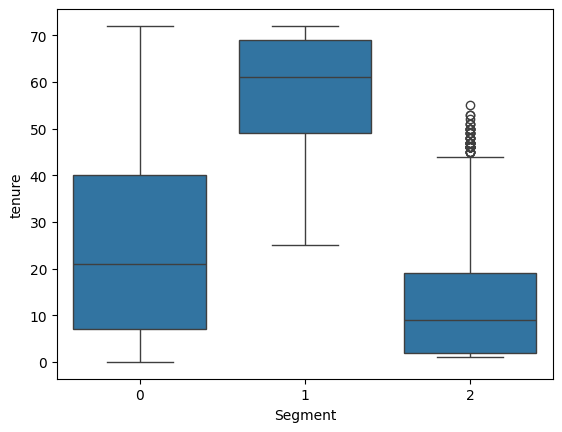

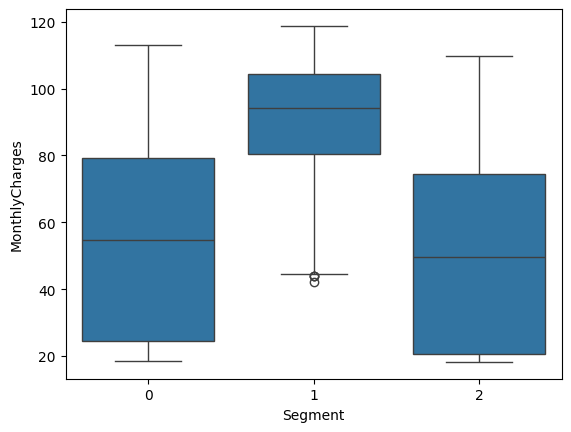

In [84]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x='Segment', y='tenure', data=df)
plt.show()

sns.boxplot(x='Segment', y='MonthlyCharges', data=df)
plt.show()

In [86]:
df.groupby('Segment')[['tenure','MonthlyCharges','TotalCharges','Churn']].mean()

,tenure,MonthlyCharges,TotalCharges,Churn
Segment,,,,
0,25.763880,54.056054,1381.625753,0.276923
1,57.906108,91.071832,4301.654057,0.161349
2,12.861754,50.929209,5043.439484,0.369554


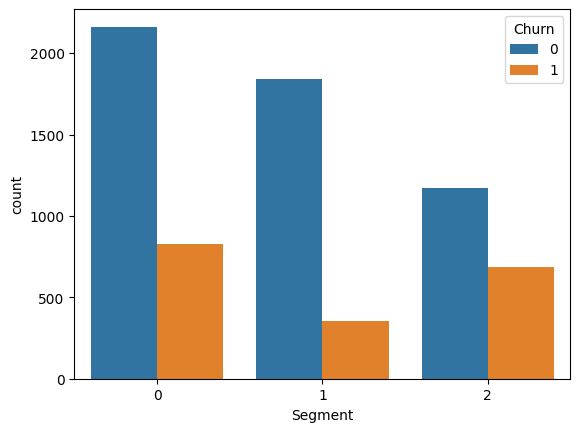

In [87]:
sns.countplot(x='Segment', hue='Churn', data=df)
plt.show()

Segments show distinct patterns

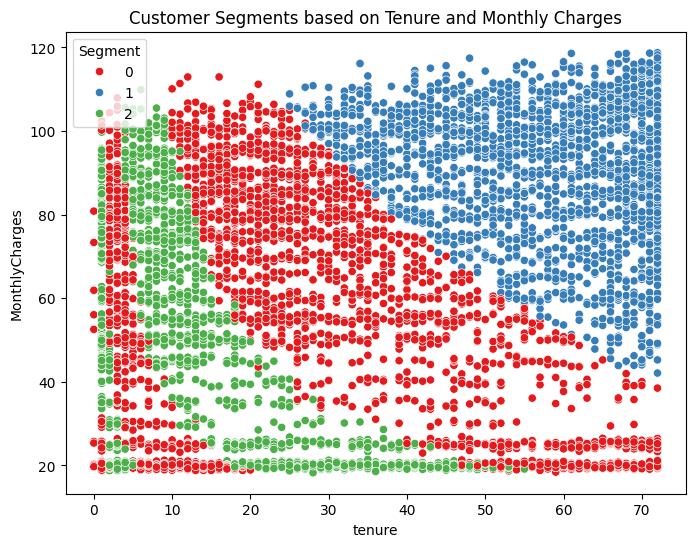

In [88]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.scatterplot(
    x='tenure',
    y='MonthlyCharges',
    hue='Segment',
    palette='Set1',
    data=df
)

plt.title("Customer Segments based on Tenure and Monthly Charges")
plt.show()

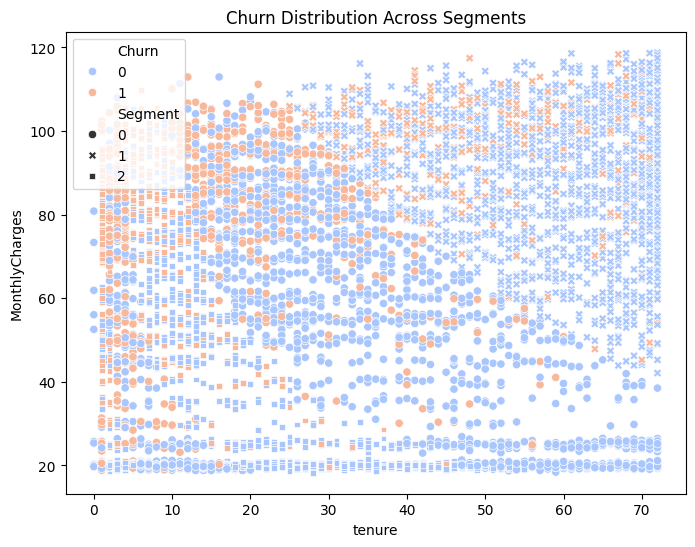

In [90]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    x='tenure',
    y='MonthlyCharges',
    hue='Churn',
    style='Segment',
    palette='coolwarm',
    data=df
)

plt.title("Churn Distribution Across Segments")
plt.show()

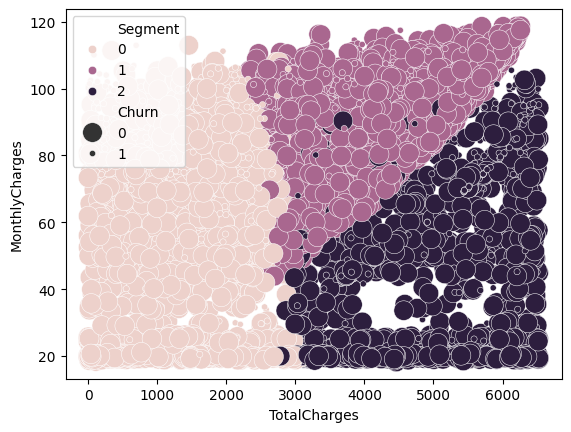

In [91]:
sns.scatterplot(
    x='TotalCharges',
    y='MonthlyCharges',
    hue='Segment',
    size='Churn',
    sizes=(20,200),
    data=df
)
plt.show()